In [71]:
library(data.table)
library(plyr)
library(vespa)
library(viper)
library(reshape2)
library(pheatmap)
library(tidyverse)
library(ggplot2)
library(igraph)
library(ggraph)

In [2]:
get_vpmx<-function(osw, spregulon, aregulon, library) {
  # VESPA (substrate-protein)
  spvpl<-viperize(osw, spregulon, xc=TRUE, normalize=TRUE)
  spvpmx<-reshape2::dcast(spvpl,protein_id~tag,value.var="nes",fill=0)
  spvpmx_proteins<-spvpmx$protein_id
  spvpmx$protein_id<-NULL
  spvpmx<-as.matrix(spvpmx)
  row.names(spvpmx)<-spvpmx_proteins
  
  # VESPA (substrate-protein)
  spvpl2<-viperize(osw, spregulon, xc=TRUE, normalize=FALSE)
  spvpmx2<-reshape2::dcast(spvpl2,protein_id~tag,value.var="nes",fill=0)
  spvpmx2_proteins<-spvpmx2$protein_id
  spvpmx2$protein_id<-NULL
  spvpmx2<-as.matrix(spvpmx2)
  row.names(spvpmx2)<-spvpmx2_proteins
  
  # VESPA (activity-protein)
  apvpl<-viperize(vmx2pv(spvpmx2, fasta=library), aregulon, xc=TRUE, normalize=TRUE)
  apvpmx<-reshape2::dcast(apvpl,protein_id~tag,value.var="nes",fill=0)
  apvpmx_proteins<-apvpmx$protein_id
  apvpmx$protein_id<-NULL
  apvpmx<-as.matrix(apvpmx)
  row.names(apvpmx)<-apvpmx_proteins
  
  # integrate substrate and activity-levels
  ipvpl<-ddply(rbind(melt(spvpmx),melt(apvpmx)),.(Var1,Var2),function(X){data.frame("value"=sum(X$value)/sqrt(length(X$value)))})
  ipvpmx<-dcast(ipvpl, Var1~Var2, value.var="value")
  ipvpmx_proteins<-ipvpmx$Var1
  ipvpmx<-as.matrix(ipvpmx[,-1])
  rownames(ipvpmx)<-ipvpmx_proteins
  
  ipvpmx<-ipvpmx[,colnames(apvpmx)]
  
  return(list("substrate"=spvpmx, "activity"=apvpmx, "integrated"=ipvpmx))
}

In [3]:
viperize<-function(osw, regulon, min_size = 10, topn = 500, xc = TRUE, normalize = TRUE){
  # generate quantitative matrix
  qmn<-export2mx(osw, fillvalues = "colmin")
  
  if (normalize) {
    # rank based normalization of the matrix
    qmn.d1 <- t(t(apply(qmn, 2, rank, na.last = "keep"))/(colSums(!is.na(qmn)) + 1))
    
    # rank based estimation of single sample gene expression signature across the matrix
    qmn.norm <- t(apply(qmn.d1, 1, rank, na.last = "keep"))/(rowSums(!is.na(qmn.d1)) + 1)
  } else {
    qmn.norm <- qmn
  }
  
  # run VIPER
  vpres<-viper(qmn.norm, vespa::pruneRegulon(vespa::subsetRegulon(regulon, rownames(qmn.norm), min_size=min_size), cutoff=topn), minsize=min_size, pleiotropy = xc, pleiotropyArgs = list(regulators = 0.05, shadow = 0.05, targets = 5, penalty = 20, method = "adaptive"), cores=6)
  
  # transform viper results
  vpd<-as.data.frame(vpres)
  vpd$protein_id<-row.names(vpd)
  vpl<-reshape2::melt(vpd, id=c("protein_id"), variable.name = "tag", value.name = "nes")

  return(vpl)
}

In [4]:
cptac <- readRDS("./data/cptac-luad/processed/CPTAC_LUAD_phospho.rds")
library <- "./tools/references/library.fasta"
spregulon <- readRDS("./runs/cptac-luad/vespa.net/results/stdpimeta_substrate_protein_regulon.rds")
aregulon <- readRDS("./runs/cptac-luad/vespa.net/results/dpimeta_activity_protein_regulon.rds")

In [5]:
vpmx <- get_vpmx(cptac, spregulon, aregulon, library)


Computing the association scores


Computing the association scores

Loading FASTA DB


Computing the association scores



In [6]:
vpmx

,11LU013,11LU016,11LU022,11LU035,C3L.00001,C3L.00009,C3L.00080,C3L.00083,C3L.00093,C3L.00094,⋯,C3N.02422,C3N.02423,C3N.02424,C3N.02433,C3N.02529,C3N.02572,C3N.02582,C3N.02586,C3N.02588,C3N.02729
A2A3K4,2.9625897,1.34815734,-1.43414661,-2.4064447,-0.90585226,3.452776194,2.24766282,4.52468233,-0.32739365,4.06994182,⋯,-1.91226151,1.36031118,0.24597796,2.73557998,-1.29220971,-1.34840486,-1.21674707,2.20381223,-1.01923715,-1.757077640
A6NDG6,1.6675610,0.52244042,1.59551720,1.2221365,0.22941887,1.205095786,0.79766021,0.27341539,1.31781492,0.44758812,⋯,-1.54205545,0.65557121,-0.45521717,-0.69930482,-1.45906986,0.12893315,-0.09181851,-1.06967786,1.10517959,0.696717067
O00418,-1.5989210,1.06918478,1.48069460,1.6790391,1.61259585,-1.404467120,1.41989205,0.46907682,-4.74656438,1.24483003,⋯,-0.76075955,-1.16800338,3.62717061,-1.73310197,2.24022504,-0.30032291,2.93962912,2.10638263,-0.07429218,9.187376044
O00506,4.7370310,6.58549298,-1.90724079,-2.2104749,5.71969695,-1.529361553,-5.24629376,1.37630252,-1.32040537,-1.68799706,⋯,-7.04877252,-1.75703057,-1.19840474,-0.78912739,0.70490324,-0.66213060,0.34151578,-1.80056061,-6.61944825,1.860384773
O00743,1.4788975,-0.67174279,0.57056782,1.2332321,-0.35804205,0.008843493,0.50773025,0.15201100,-0.10768176,1.05418600,⋯,0.11975763,1.27225161,-1.44620659,-0.59292721,0.50987611,-0.78727361,-0.82803851,-0.97791932,0.74954314,-1.796063486
O00757,0.7647635,0.08311772,-2.43360910,0.6173422,-0.02571506,-0.068094717,0.84010519,-1.41973840,-0.04316102,-3.29070369,⋯,0.05871648,-3.06148741,0.02125912,0.04392456,0.08360044,0.00259623,-0.12096121,-0.11188665,-0.03975088,1.388551432
O14495,1.6813047,-0.38116299,-0.59058642,-0.3286454,-0.81018155,1.310046671,3.07455299,4.07476663,-1.41794407,-0.16578657,⋯,0.84215198,-2.25047968,0.16209442,-2.25804722,1.40617469,0.20337863,0.68521397,-0.81284026,-1.62520939,0.072298560
O14578,-0.5892166,-1.49766805,2.37560695,1.8507995,-0.72408134,-0.928637932,-0.55345449,-0.88757066,-1.05126006,1.81018806,⋯,1.53105960,-0.49967107,2.45937054,-1.26422836,0.53355664,1.38228924,0.06231629,0.73058414,-1.83439688,-0.001996586
O14595,-1.4407092,3.55431252,1.66590720,1.5966396,4.89431488,-0.884096055,-1.42735924,0.14632016,-1.94780690,4.85105221,⋯,0.82979583,-1.02402672,-1.05933096,2.51017546,2.27428473,2.82725303,-1.23184067,-1.28458682,-0.69880621,-1.425868447
O14730,-0.8206559,-15.61847365,5.67054597,7.2534820,-4.55828138,-5.007232716,4.94299013,-1.63890947,1.56480945,1.39942293,⋯,-1.94664383,2.72686907,0.96126940,-0.08618734,-4.42886233,-0.77021695,-1.45033555,-0.56612233,3.56424858,0.571459763


In [7]:
common_enzymes <- Reduce(
  intersect,
  list(
    rownames(vpmx$substrate),
    rownames(vpmx$activity),
    rownames(vpmx$integrated)
  )
)

length(common_enzymes)

[1] 262

In [8]:
sub_common <- vpmx$substrate[common_enzymes, ]
act_common <- vpmx$activity[common_enzymes, ]
int_common <- vpmx$integrated[common_enzymes, ]

In [9]:
cor(
  as.vector(sub_common),
  as.vector(act_common),
  use = "complete.obs",
  method = "spearman"
)

cor(
  as.vector(sub_common),
  as.vector(int_common),
  use = "complete.obs",
  method = "spearman"
)

cor(
  as.vector(act_common),
  as.vector(int_common),
  use = "complete.obs",
  method = "spearman"
)

[1] 0.5843532

[1] 0.927734

[1] 0.8271828

In [6]:
graph <- readRDS("./runs/cptac-luad/vespa.net/results/CPTAC_LUAD/dpi_activity_siteregulon.rds")
graph

$`AAK1:Q2M2I8:PV`
$`AAK1:Q2M2I8:PV`$tfmode
   ABL1:P00519:PV    ABL2:P42684:PV    AKT3:Q9Y243:PV   ALPK1:Q96QP1:PV 
       0.99986474        0.99989527        0.99848336        0.99999833 
  AURKA:O14965:PV   BMP2K:Q9NSY1:PV    BRAF:P15056:PV  CAMKK1:Q8N5S9:PV 
       0.99924172        0.99999989        0.99999825        0.99999744 
 CAMKK2:Q96RR4:PV   CDK13:Q14004:PV   CDK14:O94921:PV   CDK16:Q00536:PV 
       0.99995667        0.99997517        0.99999556        0.99999500 
  CDK18:Q07002:PV  CSNK1D:P48730:PV CTDSPL2:Q05D32:PV  CTDSPL:O15194:PV 
       0.99995201        0.99999822        0.93356910        0.98470485 
  DAPK2:Q9UIK4:PV   DUSP6:Q16828:PV   DYRK2:Q92630:PV   EEF2K:O00418:PV 
       0.99970749        0.57779518        0.99999704        0.99999769 
EIF2AK1:Q9BQI3:PV   ERBB3:P21860:PV     ILK:Q13418:PV  INPP5E:Q9NRR6:PV 
       0.99999931        0.99265304        0.95315680        0.99760381 
 INPP5J:Q15735:PV   LATS1:O95835:PV   LATS2:Q9NRM7:PV   LMTK2:Q8IWU2:PV 
       0

In [11]:
edge_table <- do.call(
  rbind,
  lapply(names(graph), function(reg) {
    x <- graph[[reg]]

    data.frame(
      source  = x$meta$regulator,
      target     = names(x$tfmode),
      weight     = as.numeric(x$tfmode),
      likelihood = as.numeric(x$likelihood),
      prior      = as.numeric(x$prior),
      dataset    = x$meta$dataset,
      stringsAsFactors = FALSE
    )
  })
)

head(edge_table)
dim(edge_table)

,source,target,weight,likelihood,prior,dataset
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
1,AAK1:Q2M2I8:PV,ABL1:P00519:PV,0.9998647,0.4963142,1,results/CPTAC_LUAD/dpi_activity_siteregulon/network.txt
2,AAK1:Q2M2I8:PV,ABL2:P42684:PV,0.9998953,0.4476857,1,results/CPTAC_LUAD/dpi_activity_siteregulon/network.txt
3,AAK1:Q2M2I8:PV,AKT3:Q9Y243:PV,0.9984834,0.4658637,1,results/CPTAC_LUAD/dpi_activity_siteregulon/network.txt
4,AAK1:Q2M2I8:PV,ALPK1:Q96QP1:PV,0.9999983,0.5013381,1,results/CPTAC_LUAD/dpi_activity_siteregulon/network.txt
5,AAK1:Q2M2I8:PV,AURKA:O14965:PV,0.9992417,0.4665033,1,results/CPTAC_LUAD/dpi_activity_siteregulon/network.txt
6,AAK1:Q2M2I8:PV,BMP2K:Q9NSY1:PV,0.9999999,0.4968539,1,results/CPTAC_LUAD/dpi_activity_siteregulon/network.txt


[1] 34054     6

In [26]:
g <- graph_from_data_frame(
  d = edge_table,
  directed = TRUE
)

g <- simplify(
  g,
  remove.multiple = TRUE,
  remove.loops = FALSE,
  edge.attr.comb = list(
    weight = "mean",
    likelihood = "mean",
    prior = "mean",
    dataset = function(x) paste(unique(x), collapse = ";"),
    "ignore"
  )
)

E(g)$weight <- ifelse(is.na(E(g)$weight), 1, E(g)$weight)
E(g)$strength <- abs(E(g)$weight) *E(g)$likelihood
E(g)$distance <- 1 / (E(g)$strength + 1e-6)

g

IGRAPH a44b0ed DNW- 973 34054 -- 
+ attr: name (v/c), weight (e/n), likelihood (e/n), prior (e/n),
| dataset (e/c), strength (e/n), distance (e/n)
+ edges from a44b0ed (vertex names):
 [1] AAK1:Q2M2I8:PV->ABL1:P00519:PV   AAK1:Q2M2I8:PV->ABL2:P42684:PV  
 [3] AAK1:Q2M2I8:PV->AKT3:Q9Y243:PV   AAK1:Q2M2I8:PV->ALPK1:Q96QP1:PV 
 [5] AAK1:Q2M2I8:PV->AURKA:O14965:PV  AAK1:Q2M2I8:PV->BMP2K:Q9NSY1:PV 
 [7] AAK1:Q2M2I8:PV->BRAF:P15056:PV   AAK1:Q2M2I8:PV->CAMKK1:Q8N5S9:PV
 [9] AAK1:Q2M2I8:PV->CAMKK2:Q96RR4:PV AAK1:Q2M2I8:PV->CDK13:Q14004:PV 
[11] AAK1:Q2M2I8:PV->CDK14:O94921:PV  AAK1:Q2M2I8:PV->CDK16:Q00536:PV 
[13] AAK1:Q2M2I8:PV->CDK18:Q07002:PV  AAK1:Q2M2I8:PV->CSNK1D:P48730:PV
+ ... omitted several edges

In [30]:
num_nodes <- vcount(g)
num_edges <- ecount(g)

num_nodes
num_edges

num_self_loops <- sum(which_loop(g))
num_self_loops

# degree
deg_all <- degree(g, mode = "all")
deg_in <- degree(g, mode = "in")
deg_out <- degree(g, mode = "out")

summary(deg_all)
summary(deg_in)
summary(deg_out)

# connected components
g_und <- as_undirected(
  g,
  mode = "collapse",
  edge.attr.comb = list(
    weight = "mean",
    distance = "mean",
    likelihood = "mean",
    prior = "mean",
    strength = "mean",
    "ignore"
  )
)

comp <- components(g_und)

table(comp$csize)

largest_component_size <- max(comp$csize)
largest_component_fraction <- largest_component_size / vcount(g_und)

largest_component_size
largest_component_fraction

# node degree table
degree_tbl <- tibble(
  node = names(deg_all),
  degree_all = as.numeric(deg_all),
  indegree = as.numeric(deg_in),
  outdegree = as.numeric(deg_out)
) %>%
  arrange(desc(degree_all))

head(degree_tbl, 30)

[1] 973

[1] 34054

[1] 0

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      1       3      54      70     104     310 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      0       0      38      35      58     136 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      1       3      11      35      38     310 


973 
  1 

[1] 973

[1] 1

node,degree_all,indegree,outdegree
<chr>,<dbl>,<dbl>,<dbl>
AURKA:O14965:PA,310,0,310
DDR2:Q16832:PA,310,0,310
PPM1D:O15297:PA,302,0,302
PTPRZ1:P23471:PA,299,0,299
MYO3B:Q8WXR4:PA,291,0,291
PTPDC1:A2A3K4:PA,291,0,291
CSNK1G2:P78368:PA,288,0,288
EPHA1:P21709:PA,288,0,288
HIPK3:Q9H422:PA,284,0,284


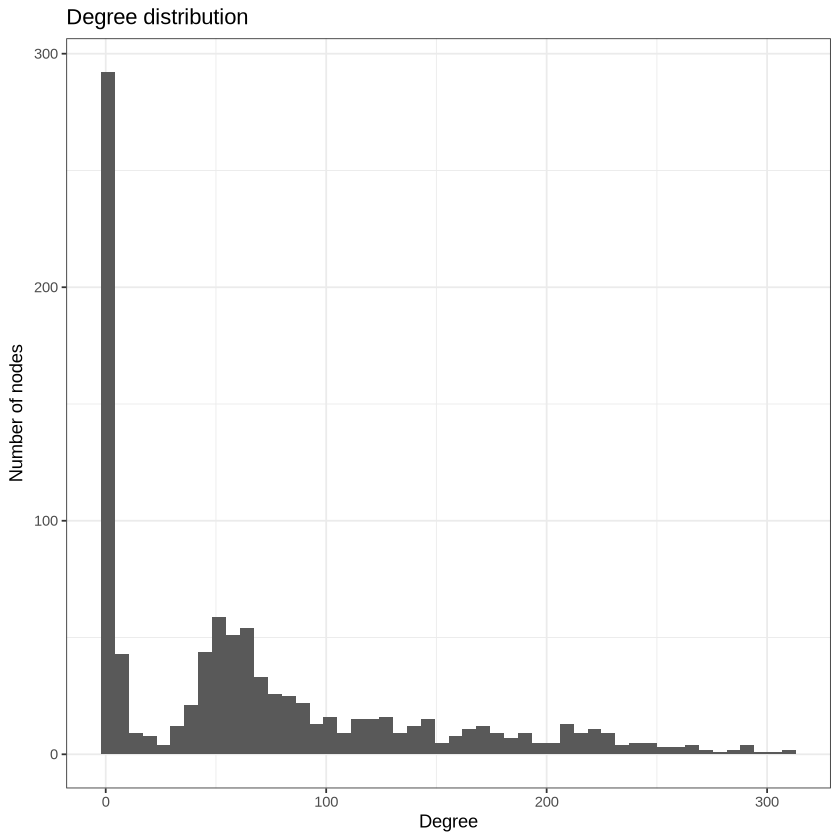

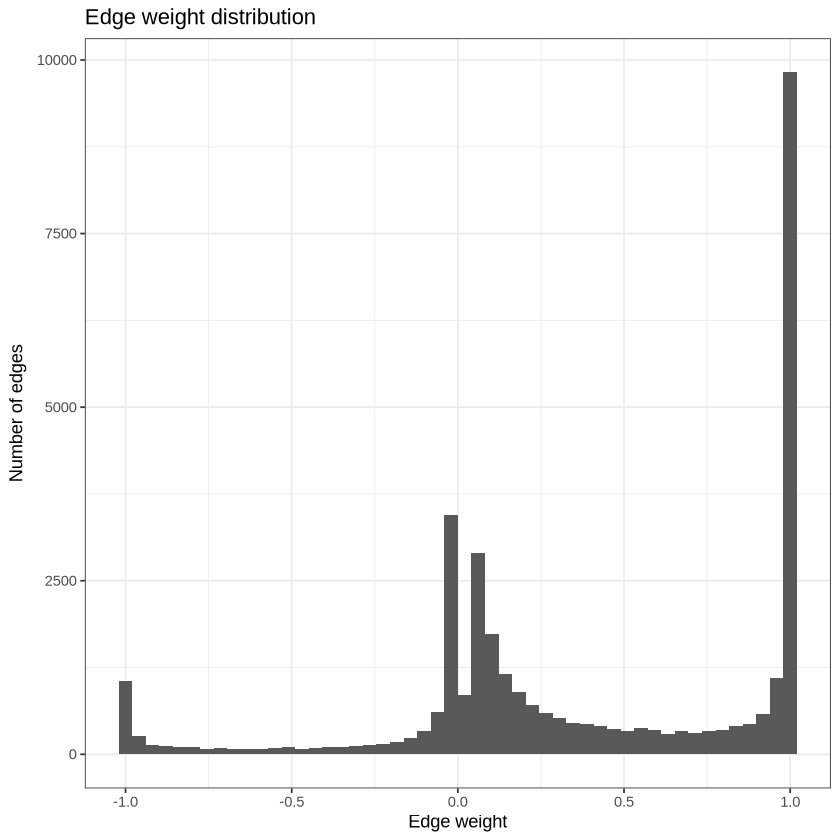

In [24]:
ggplot(degree_tbl, aes(x = degree_all)) +
  geom_histogram(bins = 50) +
  theme_bw() +
  labs(
    title = "Degree distribution",
    x = "Degree",
    y = "Number of nodes"
  )

edge_weight_tbl <- tibble(
  weight = E(g)$weight
)

ggplot(edge_weight_tbl, aes(x = weight)) +
  geom_histogram(bins = 50) +
  theme_bw() +
  labs(
    title = "Edge weight distribution",
    x = "Edge weight",
    y = "Number of edges"
  )

In [34]:
cent_tbl <- tibble(
  node = V(g)$name,
  degree_all = degree(g, mode = "all"),
  indegree = degree(g, mode = "in"),
  outdegree = degree(g, mode = "out"),
  betweenness = betweenness(g, directed = TRUE, weights = E(g)$distance, normalized = TRUE),
  harmonic = harmonic_centrality(g, mode = "all", weights = E(g)$distance),
  pagerank = page_rank(g, directed = TRUE, weights = E(g)$strength)$vector
)

# eigen centrality は undirected graph で計算
eigen_vec <- eigen_centrality(g_und, weights = E(g_und)$strength)$vector

eigen_tbl <- tibble(
  node = names(eigen_vec),
  eigen = as.numeric(eigen_vec)
)

cent_tbl <- cent_tbl %>%
  left_join(eigen_tbl, by = "node") %>%
  arrange(desc(pagerank))

In [37]:
cent_tbl %>% arrange(desc(pagerank)) %>% head(20)
cent_tbl %>% arrange(desc(eigen)) %>% head(20)
cent_tbl %>% arrange(desc(betweenness)) %>% head(20)
cent_tbl %>% arrange(desc(harmonic)) %>% head(20)
cent_tbl %>% arrange(desc(indegree)) %>% head(20)
cent_tbl %>% arrange(desc(outdegree)) %>% head(20)

node,degree_all,indegree,outdegree,betweenness,harmonic,pagerank,eigen
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TAOK3:Q9H2K8:PV,138,92,46,0.012099867,186.1489,0.007011959,0.2178628
LYN:P07948:PV,138,86,52,0.012081855,186.3927,0.006871285,0.1923796
ROCK1:Q13464:PV,144,97,47,0.004238132,182.9285,0.006594731,0.1994500
NUAK1:O60285:PV,145,91,54,0.007989939,185.2130,0.006549033,0.1968165
PRKDC:P78527:PV,149,93,56,0.009043115,192.6224,0.006544122,0.2434354
CLK2:P49760:PV,169,109,60,0.005137676,188.0875,0.006523804,0.2243441
GRK2:P25098:PV,139,95,44,0.003631020,178.0909,0.006442477,0.2031847
WEE1:P30291:PV,160,103,57,0.003242171,186.4124,0.006293876,0.2116903
MAPK6:Q16659:PV,144,96,48,0.005162045,182.1134,0.006214507,0.1908175


node,degree_all,indegree,outdegree,betweenness,harmonic,pagerank,eigen
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CAMKK1:Q8N5S9:PV,263,134,129,0.008135095,217.1599,0.003456471,1.0000000
MINK1:Q8N4C8:PV,246,126,120,0.008223036,217.9898,0.003200663,0.9954572
MARK2:Q7KZI7:PV,256,133,123,0.004475468,215.5594,0.003218844,0.9732488
NEK11:Q8NG66:PV,254,136,118,0.005217141,213.8230,0.003478836,0.9429548
MAP3K2:Q9Y2U5:PV,224,116,108,0.004245549,214.8833,0.002867405,0.9382439
NEK1:Q96PY6:PV,226,117,109,0.003388387,211.8874,0.002935524,0.9276701
MAST4:O15021:PV,240,128,112,0.003124563,211.7704,0.002898139,0.9056924
MAST2:Q6P0Q8:PV,219,113,106,0.003156349,207.9507,0.002748108,0.8691299
PIK3R4:Q99570:PV,227,118,109,0.004434146,212.0980,0.002849969,0.8535240


node,degree_all,indegree,outdegree,betweenness,harmonic,pagerank,eigen
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PTPN6:P29350:PV,177,77,100,0.030640636,197.4369,0.005583608,0.6200813
PPP1CB:P62140:PV,166,90,76,0.016278666,188.8335,0.005357865,0.4188239
IMPA2:O14732:PV,165,73,92,0.015369586,194.3838,0.004418882,0.6601561
DUSP3:P51452:PV,153,84,69,0.014470043,184.8855,0.004564328,0.3891692
PKMYT1:Q99640:PV,163,104,59,0.013370247,173.7310,0.003338621,0.1967561
PGAM1:P18669:PV,134,71,63,0.012890279,186.4093,0.004341974,0.4373932
CTDSPL:O15194:PV,172,118,54,0.012396537,209.2396,0.002790343,0.6878302
TAOK3:Q9H2K8:PV,138,92,46,0.012099867,186.1489,0.007011959,0.2178628
LYN:P07948:PV,138,86,52,0.012081855,186.3927,0.006871285,0.1923796


node,degree_all,indegree,outdegree,betweenness,harmonic,pagerank,eigen
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MINK1:Q8N4C8:PV,246,126,120,0.008223036,217.9898,0.003200663,0.9954572
CAMKK1:Q8N5S9:PV,263,134,129,0.008135095,217.1599,0.003456471,1.0000000
MARK2:Q7KZI7:PV,256,133,123,0.004475468,215.5594,0.003218844,0.9732488
MAP3K2:Q9Y2U5:PV,224,116,108,0.004245549,214.8833,0.002867405,0.9382439
NEK11:Q8NG66:PV,254,136,118,0.005217141,213.8230,0.003478836,0.9429548
PIK3R4:Q99570:PV,227,118,109,0.004434146,212.0980,0.002849969,0.8535240
NEK1:Q96PY6:PV,226,117,109,0.003388387,211.8874,0.002935524,0.9276701
MAST4:O15021:PV,240,128,112,0.003124563,211.7704,0.002898139,0.9056924
PTPN11:Q06124:PV,182,127,55,0.011338063,211.2090,0.003281973,0.7297056


node,degree_all,indegree,outdegree,betweenness,harmonic,pagerank,eigen
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NEK11:Q8NG66:PV,254,136,118,0.005217141,213.8230,0.003478836,0.9429548
CAMKK1:Q8N5S9:PV,263,134,129,0.008135095,217.1599,0.003456471,1.0000000
MARK2:Q7KZI7:PV,256,133,123,0.004475468,215.5594,0.003218844,0.9732488
DAPK2:Q9UIK4:PV,250,132,118,0.004032583,206.9763,0.003134574,0.8373431
MAST4:O15021:PV,240,128,112,0.003124563,211.7704,0.002898139,0.9056924
PTPN11:Q06124:PV,182,127,55,0.011338063,211.2090,0.003281973,0.7297056
MINK1:Q8N4C8:PV,246,126,120,0.008223036,217.9898,0.003200663,0.9954572
HIPK1:Q86Z02:PV,239,126,113,0.007337266,207.7996,0.003146530,0.8446447
PPP3CB:P16298:PV,171,124,47,0.010572021,203.1471,0.003266898,0.6550641


node,degree_all,indegree,outdegree,betweenness,harmonic,pagerank,eigen
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AURKA:O14965:PA,310,0,310,0,182.0651,0.0001541624,0.34995702
DDR2:Q16832:PA,310,0,310,0,155.4828,0.0001541624,0.35465970
PPM1D:O15297:PA,302,0,302,0,148.6031,0.0001541624,0.08640142
PTPRZ1:P23471:PA,299,0,299,0,132.6553,0.0001541624,0.05696139
MYO3B:Q8WXR4:PA,291,0,291,0,145.3186,0.0001541624,0.19180911
PTPDC1:A2A3K4:PA,291,0,291,0,144.0941,0.0001541624,0.06313719
CSNK1G2:P78368:PA,288,0,288,0,163.8540,0.0001541624,0.31368724
EPHA1:P21709:PA,288,0,288,0,152.4407,0.0001541624,0.24244217
HIPK3:Q9H422:PA,284,0,284,0,168.5265,0.0001541624,0.22663752


In [62]:
set.seed(123)

module <- cluster_leiden(
  g_und,
  objective_function = "modularity",
  weights = E(g_und)$strength,
  resolution = 2,
  n_iterations = 10
)

module_membership <- membership(module)

module_tbl <- tibble(
  node = names(module_membership),
  module = as.integer(module_membership)
)

module_size_tbl <- module_tbl %>%
  count(module, name = "module_size") %>%
  arrange(desc(module_size))

module_size_tbl

module,module_size
<int>,<int>
6,133
2,112
3,87
7,87
5,86
4,84
8,56
13,55
1,54


In [63]:
node_tbl <- cent_tbl %>%
  left_join(module_tbl, by = "node") %>%
  left_join(module_size_tbl, by = "module")

In [64]:
node_tbl %>%
  group_by(module) %>%
  arrange(desc(pagerank), .by_group = TRUE) %>%
  slice_head(n = 5) %>%
  ungroup()

node,degree_all,indegree,outdegree,betweenness,harmonic,pagerank,eigen,module,module_size
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
PAK1:Q13153:PV,212,109,103,0.002738893,205.8343,0.002555501,0.77494053,1,54
LMTK2:Q8IWU2:PV,209,108,101,0.001771539,189.9728,0.002460358,0.62930565,1,54
BRAF:P15056:PV,207,109,98,0.002596915,194.8117,0.002450192,0.72526649,1,54
PAK4:O96013:PV,207,110,97,0.002712405,188.4371,0.002372803,0.58046190,1,54
RPS6KA4:O75676:PV,208,116,92,0.004379050,190.4241,0.002370280,0.57850086,1,54
GRK3:P35626:PV,84,63,21,0.006769357,155.5341,0.003218372,0.03328610,2,112
PDGFRB:P09619:PV,69,54,15,0.001355143,163.3966,0.002856708,0.09808504,2,112
JAK2:O60674:PV,80,55,25,0.002775977,147.1008,0.002524110,0.02449378,2,112
PIK3CG:P48736:PV,61,45,16,0.002784453,140.9376,0.002475103,0.01702847,2,112


In [65]:
node_tbl %>%
  group_by(module) %>%
  arrange(desc(eigen), .by_group = TRUE) %>%
  slice_head(n = 5) %>%
  ungroup()

node,degree_all,indegree,outdegree,betweenness,harmonic,pagerank,eigen,module,module_size
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
PAK1:Q13153:PV,212,109,103,0.0027388929,205.8343,0.0025555010,0.77494053,1,54
BRAF:P15056:PV,207,109,98,0.0025969155,194.8117,0.0024501922,0.72526649,1,54
LMTK2:Q8IWU2:PV,209,108,101,0.0017715392,189.9728,0.0024603583,0.62930565,1,54
CSNK1D:P48730:PV,201,106,95,0.0009270914,191.7180,0.0020947234,0.60734445,1,54
BMP2K:Q9NSY1:PV,180,93,87,0.0001123105,184.1769,0.0017746368,0.58811392,1,54
INPP5F:Q9Y2H2:PV,66,38,28,0.0026445945,163.1489,0.0016422786,0.14405560,2,112
CDK10:Q15131:PA,255,0,255,0.0000000000,168.6055,0.0001541624,0.11498193,2,112
FASTK:Q14296:PA,267,0,267,0.0000000000,170.3142,0.0001541624,0.10786478,2,112
PDGFRB:P09619:PV,69,54,15,0.0013551428,163.3966,0.0028567085,0.09808504,2,112


In [66]:
node_tbl %>%
  group_by(module) %>%
  arrange(desc(outdegree), .by_group = TRUE) %>%
  slice_head(n = 5) %>%
  ungroup()

node,degree_all,indegree,outdegree,betweenness,harmonic,pagerank,eigen,module,module_size
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
PPM1L:Q5SGD2:PA,146,0,146,0.000000000,130.1083,0.0001541624,0.04381151,1,54
PAK1:Q13153:PV,212,109,103,0.002738893,205.8343,0.0025555010,0.77494053,1,54
LMTK2:Q8IWU2:PV,209,108,101,0.001771539,189.9728,0.0024603583,0.62930565,1,54
BRAF:P15056:PV,207,109,98,0.002596915,194.8117,0.0024501922,0.72526649,1,54
PAK4:O96013:PV,207,110,97,0.002712405,188.4371,0.0023728030,0.58046190,1,54
FASTK:Q14296:PA,267,0,267,0.000000000,170.3142,0.0001541624,0.10786478,2,112
CDK10:Q15131:PA,255,0,255,0.000000000,168.6055,0.0001541624,0.11498193,2,112
PTPRD:P23468:PA,240,0,240,0.000000000,154.2118,0.0001541624,0.05575787,2,112
ALPG:P10696:PA,232,0,232,0.000000000,137.0620,0.0001541624,0.05769668,2,112


In [67]:
all_nodes <- V(g)$name

egfr_nodes <- all_nodes[
  toupper(all_nodes) == "EGFR" |
    str_detect(toupper(all_nodes), "^EGFR[_:;|\\-]")
]

egfr_nodes

[1] "EGFR:P00533:PV"

In [68]:
egfr_1hop_nodes <- ego(
  graph = g,
  order = 1,
  nodes = egfr_nodes,
  mode = "all"
)

egfr_1hop_nodes <- unique(unlist(egfr_1hop_nodes))
g_egfr_1hop <- induced_subgraph(g, vids = egfr_1hop_nodes)

g_egfr_1hop

egfr_2hop_nodes <- ego(
  graph = g,
  order = 2,
  nodes = egfr_nodes,
  mode = "all"
)

egfr_2hop_nodes <- unique(unlist(egfr_2hop_nodes))
g_egfr_2hop <- induced_subgraph(g, vids = egfr_2hop_nodes)

g_egfr_2hop

IGRAPH 5e3bcf6 DNW- 92 2265 -- 
+ attr: name (v/c), weight (e/n), likelihood (e/n), prior (e/n),
| dataset (e/c), strength (e/n), distance (e/n)
+ edges from 5e3bcf6 (vertex names):
 [1] ABL1:P00519:PV->ALPK1:Q96QP1:PV    ABL1:P00519:PV->BRAF:P15056:PV    
 [3] ABL1:P00519:PV->CAMKK1:Q8N5S9:PV   ABL1:P00519:PV->CDC42BPA:Q5VT25:PV
 [5] ABL1:P00519:PV->CDK16:Q00536:PV    ABL1:P00519:PV->CDKL5:O76039:PV   
 [7] ABL1:P00519:PV->CSNK1D:P48730:PV   ABL1:P00519:PV->DUSP16:Q9BY84:PV  
 [9] ABL1:P00519:PV->EEF2K:O00418:PV    ABL1:P00519:PV->EGFR:P00533:PV    
[11] ABL1:P00519:PV->ERBB3:P21860:PV    ABL1:P00519:PV->FRK:P42685:PV     
[13] ABL1:P00519:PV->HIPK1:Q86Z02:PV    ABL1:P00519:PV->LMTK2:Q8IWU2:PV   
+ ... omitted several edges

IGRAPH ac59c42 DNW- 703 33403 -- 
+ attr: name (v/c), weight (e/n), likelihood (e/n), prior (e/n),
| dataset (e/c), strength (e/n), distance (e/n)
+ edges from ac59c42 (vertex names):
 [1] AAK1:Q2M2I8:PV->ABL1:P00519:PV   AAK1:Q2M2I8:PV->ABL2:P42684:PV  
 [3] AAK1:Q2M2I8:PV->AKT3:Q9Y243:PV   AAK1:Q2M2I8:PV->ALPK1:Q96QP1:PV 
 [5] AAK1:Q2M2I8:PV->AURKA:O14965:PV  AAK1:Q2M2I8:PV->BMP2K:Q9NSY1:PV 
 [7] AAK1:Q2M2I8:PV->BRAF:P15056:PV   AAK1:Q2M2I8:PV->CAMKK1:Q8N5S9:PV
 [9] AAK1:Q2M2I8:PV->CAMKK2:Q96RR4:PV AAK1:Q2M2I8:PV->CDK13:Q14004:PV 
[11] AAK1:Q2M2I8:PV->CDK14:O94921:PV  AAK1:Q2M2I8:PV->CDK16:Q00536:PV 
[13] AAK1:Q2M2I8:PV->CDK18:Q07002:PV  AAK1:Q2M2I8:PV->CSNK1D:P48730:PV
+ ... omitted several edges

In [69]:
egfr_1hop_node_tbl <- tibble(
  node = V(g_egfr_1hop)$name
) %>%
  left_join(node_tbl, by = "node") %>%
  arrange(desc(pagerank))

egfr_1hop_edge_tbl <- as_data_frame(g_egfr_1hop, what = "edges") %>%
  as_tibble()

egfr_1hop_node_tbl
egfr_1hop_edge_tbl


egfr_2hop_node_tbl <- tibble(
  node = V(g_egfr_2hop)$name
) %>%
  left_join(node_tbl, by = "node") %>%
  arrange(desc(pagerank))

egfr_2hop_edge_tbl <- as_data_frame(g_egfr_2hop, what = "edges") %>%
  as_tibble()

node,degree_all,indegree,outdegree,betweenness,harmonic,pagerank,eigen,module,module_size
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
CAMKK1:Q8N5S9:PV,263,134,129,0.0081350947,217.1599,0.003456471,1.00000000,13,55
PTPN11:Q06124:PV,182,127,55,0.0113380631,211.2090,0.003281973,0.72970562,3,87
NEK6:Q9HC98:PV,215,120,95,0.0027018093,191.0599,0.003222235,0.65429114,12,52
HIPK1:Q86Z02:PV,239,126,113,0.0073372663,207.7996,0.003146530,0.84464468,16,18
DUSP16:Q9BY84:PV,175,120,55,0.0080990706,210.8726,0.003059999,0.73350988,3,87
NT5C:Q8TCD5:PV,164,124,40,0.0038842481,202.4735,0.002909836,0.69996740,20,6
RIPK1:Q13546:PV,239,122,117,0.0028098816,207.8697,0.002905338,0.85156846,13,55
OXSR1:O95747:PV,203,110,93,0.0026975711,195.9151,0.002740662,0.67629412,12,52
SIK3:Q9Y2K2:PV,231,117,114,0.0050836395,209.3887,0.002736457,0.84165257,13,55


from,to,weight,likelihood,prior,dataset,strength,distance
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
ABL1:P00519:PV,ALPK1:Q96QP1:PV,0.9999903,0.5672917,1,results/CPTAC_LUAD/dpi_activity_siteregulon/network.txt,0.5672862,1.762775
ABL1:P00519:PV,BRAF:P15056:PV,0.9999906,0.5121219,1,results/CPTAC_LUAD/dpi_activity_siteregulon/network.txt,0.5121172,1.952674
ABL1:P00519:PV,CAMKK1:Q8N5S9:PV,0.9999890,0.5076852,1,results/CPTAC_LUAD/dpi_activity_siteregulon/network.txt,0.5076796,1.969742
ABL1:P00519:PV,CDC42BPA:Q5VT25:PV,0.9999412,0.5138641,1,results/CPTAC_LUAD/dpi_activity_siteregulon/network.txt,0.5138339,1.946151
ABL1:P00519:PV,CDK16:Q00536:PV,0.9999906,0.5017108,1,results/CPTAC_LUAD/dpi_activity_siteregulon/network.txt,0.5017061,1.993195
ABL1:P00519:PV,CDKL5:O76039:PV,0.9999937,0.5046416,1,results/CPTAC_LUAD/dpi_activity_siteregulon/network.txt,0.5046385,1.981613
ABL1:P00519:PV,CSNK1D:P48730:PV,0.9999988,0.5345958,1,results/CPTAC_LUAD/dpi_activity_siteregulon/network.txt,0.5345952,1.870571
ABL1:P00519:PV,DUSP16:Q9BY84:PV,0.9993926,0.4990365,1,results/CPTAC_LUAD/dpi_activity_siteregulon/network.txt,0.4987334,2.005075
ABL1:P00519:PV,EEF2K:O00418:PV,0.9999946,0.4935075,1,results/CPTAC_LUAD/dpi_activity_siteregulon/network.txt,0.4935049,2.026318


Warning message:
“`subgraph.edges()` was deprecated in igraph 2.1.0.
ℹ Please use `subgraph_from_edges()` instead.”


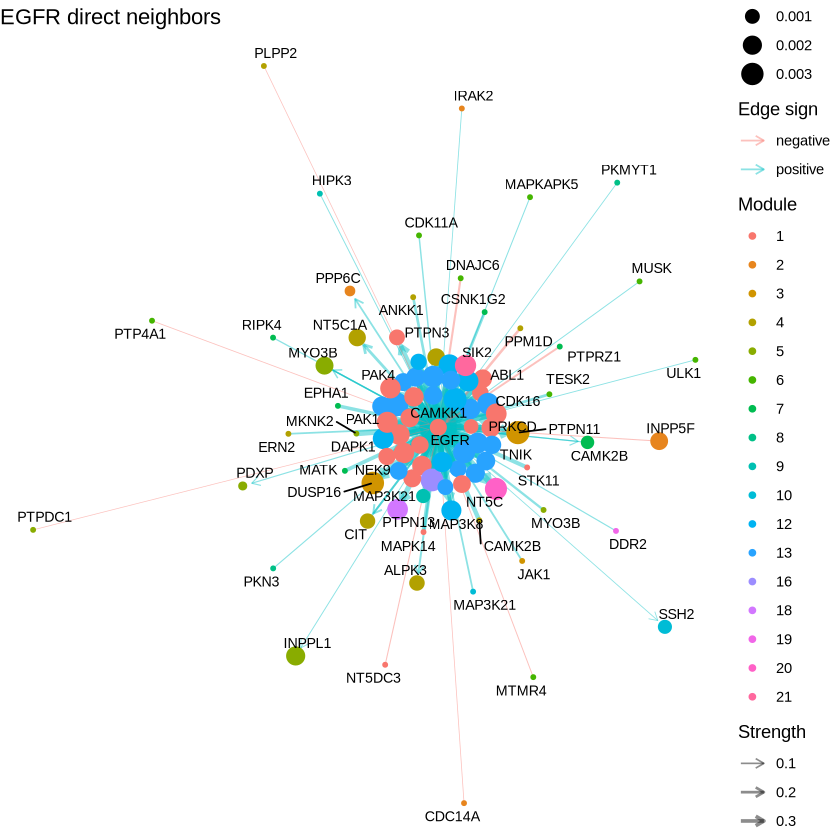

In [80]:
egfr_vid <- V(g_egfr_1hop)[name == egfr_nodes]

egfr_eids <- incident_edges(
  g_egfr_1hop,
  v = egfr_vid,
  mode = "all"
)[[1]]

g_egfr_star <- subgraph.edges(
  g_egfr_1hop,
  eids = egfr_eids,
  delete.vertices = TRUE
)


V(g_egfr_star)$module <- node_tbl$module[
  match(V(g_egfr_star)$name, node_tbl$node)
]

V(g_egfr_star)$pagerank <- node_tbl$pagerank[
  match(V(g_egfr_star)$name, node_tbl$node)
]

V(g_egfr_star)$outdegree <- node_tbl$outdegree[
  match(V(g_egfr_star)$name, node_tbl$node)
]

V(g_egfr_star)$gene <- sub(":.*", "", V(g_egfr_star)$name)

E(g_egfr_star)$edge_sign <- ifelse(E(g_egfr_star)$weight >= 0, "positive", "negative")
E(g_egfr_star)$layout_weight <- pmax(E(g_egfr_star)$strength, 1e-6)


set.seed(123)

ggraph(
  g_egfr_star,
  layout = "fr",
  weights = E(g_egfr_star)$layout_weight
) +
  geom_edge_link(
    aes(width = strength, color = edge_sign),
    alpha = 0.45,
    arrow = arrow(length = unit(2, "mm")),
    end_cap = circle(2, "mm")
  ) +
  scale_edge_width(range = c(0.2, 1.8)) +
  geom_node_point(
    aes(size = pagerank, color = as.factor(module))
  ) +
  geom_node_text(
    aes(label = gene),
    repel = TRUE,
    size = 3
  ) +
  theme_void() +
  labs(
    title = "EGFR direct neighbors",
    color = "Module",
    size = "PageRank",
    edge_width = "Strength",
    edge_color = "Edge sign"
  )

In [60]:
dir.create("./data/cptac-luad/outs")

Warning message in dir.create("./data/cptac-luad/outs"):
“'./data/cptac-luad/outs' already exists”


In [85]:
write.csv(vpmx$substrate, file="./data/cptac-luad/outs/vespa_substrate.csv")
write.csv(vpmx$activity, file="./data/cptac-luad/outs/vespa_activity.csv")
write.csv(vpmx$integrated, file="./data/cptac-luad/outs/vespa_integrated.csv")